# Análise Univariada

### Ciência de Dados · 4º período

**Instituto de Computação — Universidade Federal do Amazonas**

---

> _"Antes de perguntar como duas variáveis se relacionam,
> é preciso saber o que cada uma delas é."_

**Bases de dados usadas nesta aula (ambas reais):**

| Base   | O que é                                                | Origem                         |
| ------ | ------------------------------------------------------ | ------------------------------ |
| `rio`  | Cota diária do rio Negro no Porto de Manaus, 2000–hoje | Porto de Manaus / SGB / ANA    |
| `taxi` | Corridas de táxi (NYC, 2019) — 6.433 corridas          | Dataset público `seaborn-data` |

A primeira é nossa. A segunda entra porque tem coisas que a primeira não tem:
categórica de alta cardinalidade, cauda pesada à direita, ausências reais e valores impossíveis.


## Setup


In [1]:
# ---------------------------------------------------------------
# Bibliotecas
# ---------------------------------------------------------------
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ---------------------------------------------------------------
# Estilo dos gráficos (fontes grandes: isto vai ser projetado)
# ---------------------------------------------------------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

print("Bibliotecas carregadas.")
print("pandas", pd.__version__, "| numpy",
      np.__version__, "| seaborn", sns.__version__)

Bibliotecas carregadas.
pandas 3.0.5 | numpy 2.5.2 | seaborn 0.13.2


In [2]:
# ---------------------------------------------------------------
# BASE 1 — Cota diária do rio Negro no Porto de Manaus
# Fonte: Porto de Manaus (rede ANA/SGB), compilado em
# https://github.com/davidscamurca/nivel-rio-negro
# ---------------------------------------------------------------
URL_RIO = ("https://raw.githubusercontent.com/davidscamurca/"
           "nivel-rio-negro/main/data/rio-negro-data.json")

with urllib.request.urlopen(URL_RIO) as resposta:
    rio = pd.DataFrame(json.load(resposta))

# nivel em metros; variacao em cm/dia
rio.columns = ["data", "nivel", "variacao"]
rio["data"] = pd.to_datetime(rio["data"])

# ---------------------------------------------------------------
# BASE 2 — Corridas de táxi (Nova York, 2019)
# ---------------------------------------------------------------
URL_TAXI = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv"
taxi = pd.read_csv(URL_TAXI, parse_dates=["pickup", "dropoff"])

print(f"rio  : {rio.shape[0]:>6,} linhas x {rio.shape[1]} colunas  "
      f"({rio['data'].min():%d/%m/%Y} a {rio['data'].max():%d/%m/%Y})")
print(f"taxi : {taxi.shape[0]:>6,} linhas x {taxi.shape[1]} colunas")

rio  :  9,736 linhas x 3 colunas  (01/01/2000 a 28/08/2026)
taxi :  6,433 linhas x 14 colunas


---

# 0. O rio como variável

Uma coluna de números. Só isso.

A cota do rio Negro é medida **todos os dias** no Porto de Manaus desde setembro de 1902.
Nosso recorte começa em 2000.


In [3]:
rio.head()

,data,nivel,variacao
0,2000-01-01,19.150,15.000
1,2000-01-02,19.310,16.000
2,2000-01-03,19.470,16.000
3,2000-01-04,19.600,13.000
4,2000-01-05,19.690,9.000


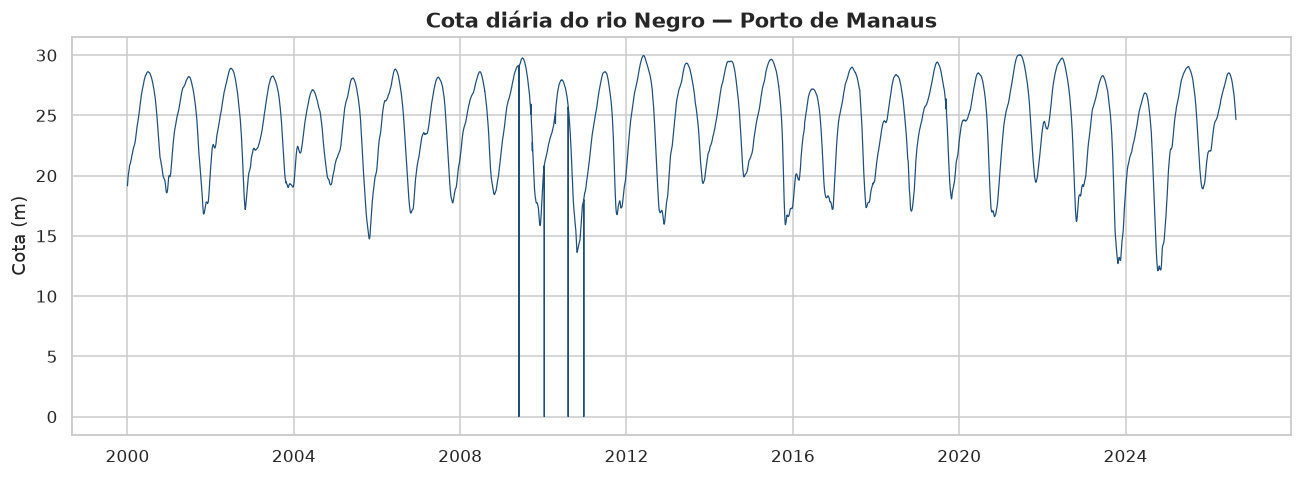

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(rio["data"], rio["nivel"], lw=0.8, color="#1f4e79")
ax.set_title("Cota diária do rio Negro — Porto de Manaus")
ax.set_xlabel("")
ax.set_ylabel("Cota (m)")
plt.tight_layout()
plt.show()

## Três perguntas que qualquer manauara já fez

1. A cheia de **2021** foi excepcional. **Quanto** de excepcional?
2. A seca de **2023–2024** foi a pior da história? Ou só a pior que _nós_ vimos?
3. O nível de **hoje** é normal para esta época?

Repare: nenhuma dessas perguntas envolve uma segunda variável.
Todas são respondidas olhando **uma coluna só**.


In [5]:
# Resposta "no braço", sem vocabulário técnico ainda
cheia_recorde = rio.loc[rio["nivel"].idxmax()]
serie_valida = rio[rio["nivel"] > 0]          # (voltaremos a este filtro!)
vazante_recorde = serie_valida.loc[serie_valida["nivel"].idxmin()]
hoje = rio.iloc[-1]

print(
    f"Maior cota registrada : {cheia_recorde['nivel']:.2f} m  em {cheia_recorde['data']:%d/%m/%Y}")
print(
    f"Menor cota registrada : {vazante_recorde['nivel']:.2f} m  em {vazante_recorde['data']:%d/%m/%Y}")
print(
    f"Última medição        : {hoje['nivel']:.2f} m  em {hoje['data']:%d/%m/%Y}")

# Em que posição relativa está a medição de hoje?
posicao = (serie_valida["nivel"] < hoje["nivel"]).mean()
print(f"\nA cota de hoje é maior que {posicao:.1%} de todos os dias da série.")

Maior cota registrada : 30.02 m  em 16/06/2021
Menor cota registrada : 12.11 m  em 09/10/2024
Última medição        : 24.65 m  em 28/08/2026

A cota de hoje é maior que 50.7% de todos os dias da série.


## O que acabamos de fazer

Em cinco linhas de código usamos:

- **máximo** e **mínimo** → medidas de posição extrema
- **ordenação** → a base de todos os quantis
- **proporção de valores abaixo de um ponto** → um percentil empírico

Isso **é** análise univariada. O resto da aula é fazer isso com
**método**, **vocabulário** e, principalmente, **desconfiança**.


## 🚩 E já apareceu um problema

Olhe de novo a linha que calcula o recorde de vazante:

```python
serie_valida = rio[rio["nivel"] > 0]
```

Por que esse filtro está aí? O que acontece se eu não filtrar?

> Guardem essa pergunta. Ela volta no **Bloco 6**.


In [6]:
# Sem o filtro:
print("Mínimo sem filtro:", rio["nivel"].min(), "m")

Mínimo sem filtro: 0.0 m


---

# 1. Tipos de variáveis e escalas de medida

Este é o bloco mais chato da aula e o mais importante.

**A escala de medida da variável determina o que você pode calcular com ela.**
Errar aqui invalida tudo o que vem depois — e o computador não avisa.


## A taxonomia

```
                        VARIÁVEL
                           │
          ┌────────────────┴────────────────┐
          │                                 │
    QUALITATIVA                       QUANTITATIVA
    (categórica)                        (numérica)
          │                                 │
   ┌──────┴──────┐                   ┌──────┴──────┐
   │             │                   │             │
NOMINAL       ORDINAL             DISCRETA      CONTÍNUA
sem ordem    com ordem            contagem      medição
```

| Escala         | Exemplo                        | Ordem? | Distância tem sentido? | Zero absoluto? |
| -------------- | ------------------------------ | :----: | :--------------------: | :------------: |
| **Nominal**    | bairro, forma de pagamento     |   ✗    |           ✗            |       ✗        |
| **Ordinal**    | escolaridade, Likert 1–5       |   ✓    |           ✗            |       ✗        |
| **Intervalar** | temperatura em °C, ano         |   ✓    |           ✓            |       ✗        |
| **Razão**      | cota do rio, tarifa, distância |   ✓    |           ✓            |       ✓        |


## Por que isso importa na prática

| Escala     | Centro             | Dispersão                     | Gráfico típico      |
| ---------- | ------------------ | ----------------------------- | ------------------- |
| Nominal    | moda               | —                             | barras              |
| Ordinal    | moda, **mediana**  | amplitude interquartil        | barras ordenadas    |
| Intervalar | + **média**        | + desvio padrão               | histograma          |
| Razão      | + média geométrica | + **coeficiente de variação** | histograma, boxplot |

Cada linha _acrescenta_ operações à anterior.
Calcular a média de uma variável ordinal (nota Likert!) é tecnicamente um abuso —
comum, às vezes tolerado, mas um abuso.


## A armadilha central

### `dtype` do pandas ≠ escala de medida

O pandas só sabe se algo é `int64`, `float64` ou `object`.
Ele **não sabe** se aquilo é uma contagem, um código ou uma medição.


In [7]:
taxi.head(3)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.600,7.000,2.150,0.000,12.950,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.790,5.000,0.000,0.000,9.300,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.370,7.500,2.360,0.000,14.160,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan


In [8]:
taxi.dtypes.to_frame("dtype do pandas")

,dtype do pandas
pickup,datetime64[us]
dropoff,datetime64[us]
passengers,int64
distance,float64
fare,float64
tip,float64
tolls,float64
total,float64
color,str
payment,str


### Pergunta para a turma

`passengers` é `int64`. `distance` é `float64`.
O pandas trata as duas como "números".

**São a mesma coisa?**

- `passengers` = 1, 2, 3... — contagem, **discreta**, não existe 2,5 passageiro
- `distance` = 1,64 mi — medição, **contínua**, poderia ter qualquer casa decimal

E se houvesse uma coluna `codigo_da_zona` com valores 101, 102, 103?
Seria `int64` também — e somar dois códigos de zona não significa nada.


## Boa prática: escrever o dicionário de variáveis à mão

Nenhuma função faz isso por você. É trabalho humano, e é rápido.


In [9]:
dicionario = pd.DataFrame([
    ("pickup",        "data/hora",   "intervalar", "início da corrida"),
    ("passengers",    "quantitativa", "razão (discreta)", "nº de passageiros"),
    ("distance",      "quantitativa", "razão (contínua)", "distância em milhas"),
    ("fare",          "quantitativa", "razão (contínua)", "tarifa base (US$)"),
    ("tip",           "quantitativa", "razão (contínua)", "gorjeta (US$)"),
    ("tolls",         "quantitativa", "razão (contínua)", "pedágios (US$)"),
    ("total",         "quantitativa", "razão (contínua)", "valor total pago (US$)"),
    ("color",         "qualitativa", "nominal",     "tipo de táxi (yellow/green)"),
    ("payment",       "qualitativa", "nominal",     "forma de pagamento"),
    ("pickup_zone",   "qualitativa", "nominal",
     "zona de embarque (194 níveis!)"),
    ("pickup_borough", "qualitativa", "nominal",     "distrito de embarque"),
], columns=["variável", "tipo", "escala", "descrição"])

dicionario

,variável,tipo,escala,descrição
0,pickup,data/hora,intervalar,início da corrida
1,passengers,quantitativa,razão (discreta),nº de passageiros
2,distance,quantitativa,razão (contínua),distância em milhas
3,fare,quantitativa,razão (contínua),tarifa base (US$)
4,tip,quantitativa,razão (contínua),gorjeta (US$)
5,tolls,quantitativa,razão (contínua),pedágios (US$)
6,total,quantitativa,razão (contínua),valor total pago (US$)
7,color,qualitativa,nominal,tipo de táxi (yellow/green)
8,payment,qualitativa,nominal,forma de pagamento
9,pickup_zone,qualitativa,nominal,zona de embarque (194 níveis!)


## Variáveis derivadas: criar a coluna certa é meio caminho

Na base do rio, `data` não é interessante por si só — mas o que dá pra extrair dela é.


In [10]:
# intervalar (ou ordinal, se usada como rótulo)
rio["ano"] = rio["data"].dt.year
# ORDINAL CÍCLICA — dezembro é vizinho de janeiro!
rio["mes"] = rio["data"].dt.month

# Fase do ciclo hidrológico: variável qualitativa nominal, derivada
rio["fase"] = np.where(rio["variacao"] > 0, "enchendo", "vazando")

rio.head(3)

,data,nivel,variacao,ano,mes,fase
0,2000-01-01,19.150,15.000,2000,1,enchendo
1,2000-01-02,19.310,16.000,2000,1,enchendo
2,2000-01-03,19.470,16.000,2000,1,enchendo


> **Atenção ao `mes`:** é `int64`, tem ordem, mas é **cíclica**.
> A "distância" entre dezembro (12) e janeiro (1) é 1 mês, não 11.
> Média de mês não faz sentido. Este é o tipo de coisa que só o
> conhecimento do domínio detecta.


---

# 2. Variáveis qualitativas

Para uma variável categórica, a distribuição **é** a tabela de frequências.
Não há mais nada. E é surpreendente quanta gente pula essa etapa.


## As três frequências

Para uma variável com categorias $c_1, c_2, \dots, c_k$ e $n$ observações:

$$
\underbrace{f_i}_{\text{absoluta}} = \#\{x = c_i\}
\qquad
\underbrace{fr_i}_{\text{relativa}} = \frac{f_i}{n}
\qquad
\underbrace{F_i}_{\text{acumulada}} = \sum_{j \le i} fr_j
$$

A **acumulada** só faz sentido se a variável for **ordinal** — ou se você
ordenar as categorias por frequência de propósito (é o que o gráfico de Pareto faz).

**Moda** = a categoria com maior $f_i$. É a única medida de centro válida em escala nominal.


In [11]:
def tabela_frequencia(serie, dropna=False):
    """Tabela de frequências completa. Por padrão MOSTRA os ausentes."""
    absoluta = serie.value_counts(dropna=dropna)
    tabela = pd.DataFrame({
        "freq_absoluta": absoluta,
        "freq_relativa": absoluta / absoluta.sum(),
    })
    tabela["freq_acumulada"] = tabela["freq_relativa"].cumsum()
    return tabela


tabela_frequencia(taxi["payment"])
# taxi["payment"]

,freq_absoluta,freq_relativa,freq_acumulada
payment,,,
credit card,4577,0.711,0.711
cash,1812,0.282,0.993
NaN,44,0.007,1.000


### Repare no `NaN`

Ele está ali, com 44 ocorrências. O padrão do pandas (`dropna=True`)
o esconderia — e as frequências relativas mudariam de base silenciosamente.

**Regra:** na primeira olhada, sempre `dropna=False`. Você precisa _ver_ o buraco.


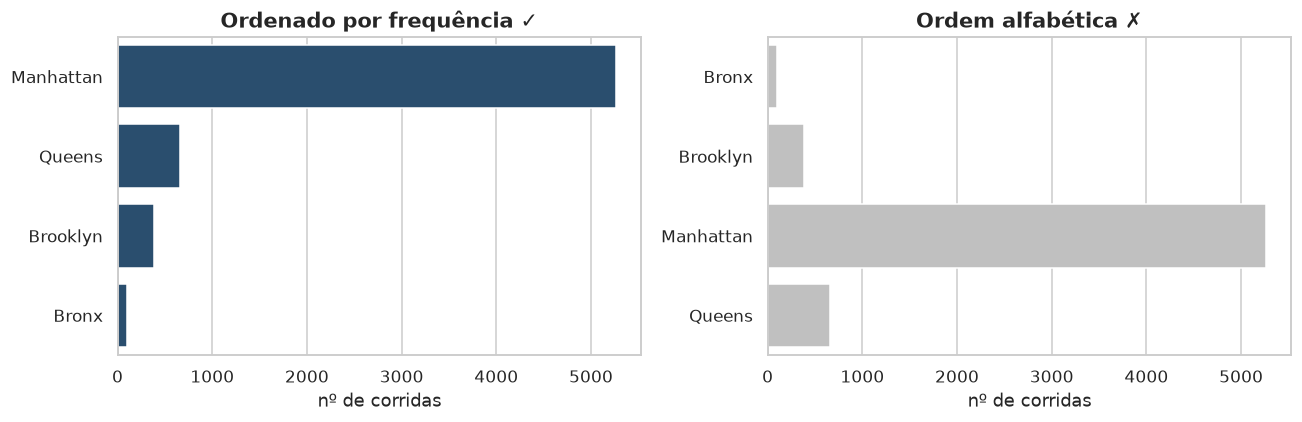

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Ordenado por frequência (correto para NOMINAL)
ordem = taxi["pickup_borough"].value_counts().index
sns.countplot(data=taxi, y="pickup_borough",
              order=ordem, ax=axes[0], color="#1f4e79")
axes[0].set_title("Ordenado por frequência ✓")
axes[0].set_xlabel("nº de corridas")
axes[0].set_ylabel("")

# Ordem alfabética (arbitrária, esconde o padrão)
sns.countplot(data=taxi, y="pickup_borough",
              order=sorted(taxi["pickup_borough"].dropna().unique()),
              ax=axes[1], color="#c0c0c0")
axes[1].set_title("Ordem alfabética ✗")
axes[1].set_xlabel("nº de corridas")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

> Para variável **nominal**, ordene por frequência.
> Para variável **ordinal**, ordene pela ordem natural — _nunca_ por frequência.


## Alta cardinalidade: o problema real

`pickup_zone` tem **194 categorias**. Um gráfico de barras com 194 barras
não é um gráfico, é uma parede.


In [13]:
freq_zonas = taxi["pickup_zone"].value_counts()
print(f"Número de zonas distintas: {taxi['pickup_zone'].nunique()}")
print(f"Zonas que aparecem 1 única vez: {(freq_zonas == 1).sum()}")
print(f"\nAs 10 zonas mais frequentes concentram "
      f"{freq_zonas.head(10).sum() / freq_zonas.sum():.1%} das corridas.")

Número de zonas distintas: 194
Zonas que aparecem 1 única vez: 31

As 10 zonas mais frequentes concentram 30.4% das corridas.


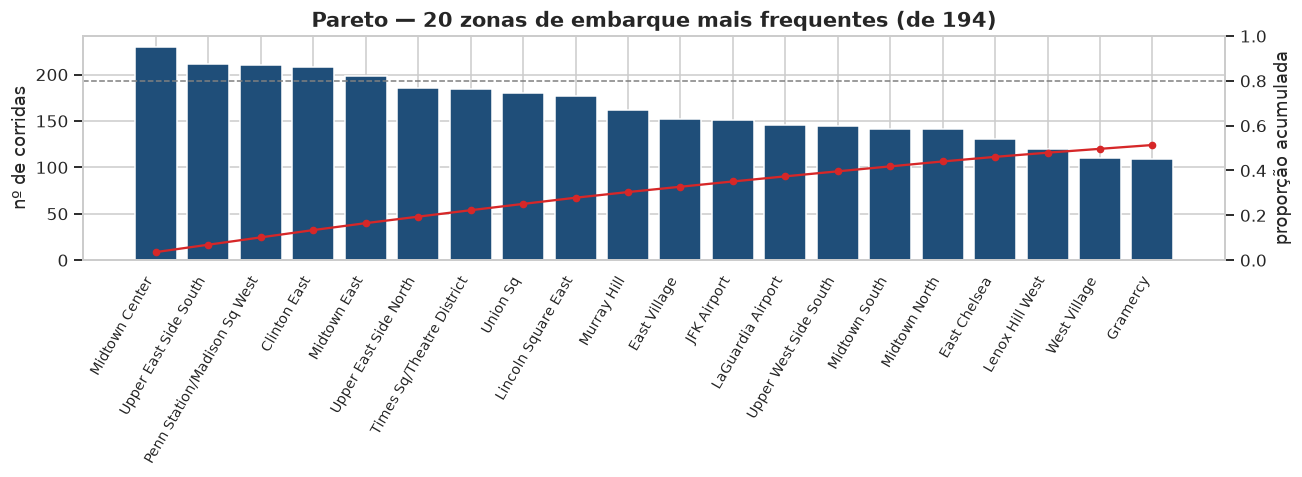

In [14]:
# Gráfico de Pareto: barras (freq) + linha (freq acumulada)
top = freq_zonas.head(20)
acumulada = freq_zonas.cumsum() / freq_zonas.sum()

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.bar(range(len(top)), top.values, color="#1f4e79")
ax1.set_xticks(range(len(top)))
ax1.set_xticklabels(top.index, rotation=60, ha="right", fontsize=9)
ax1.set_ylabel("nº de corridas")

ax2 = ax1.twinx()
ax2.plot(range(len(top)), acumulada.head(
    20).values, color="#d62728", marker="o", ms=4)
ax2.axhline(0.8, ls="--", color="gray", lw=1)
ax2.set_ylabel("proporção acumulada")
ax2.set_ylim(0, 1)
ax2.grid(False)

ax1.set_title("Pareto — 20 zonas de embarque mais frequentes (de 194)")
plt.tight_layout()
plt.show()

In [15]:
# Estratégia prática: top-k + "Outros"
K = 8
principais = freq_zonas.head(K).index
taxi["zona_agrupada"] = taxi["pickup_zone"].where(
    taxi["pickup_zone"].isin(principais), other="Outros"
)
tabela_frequencia(taxi["zona_agrupada"])

,freq_absoluta,freq_relativa,freq_acumulada
zona_agrupada,,,
Outros,4826,0.750,0.750
Midtown Center,230,0.036,0.786
Upper East Side South,211,0.033,0.819
Penn Station/Madison Sq West,210,0.033,0.851
Clinton East,208,0.032,0.884
Midtown East,198,0.031,0.915
Upper East Side North,186,0.029,0.943
Times Sq/Theatre District,184,0.029,0.972
Union Sq,180,0.028,1.000


## Sobre gráfico de pizza

Não é proibido. É só quase sempre pior.

- O olho humano compara **comprimentos** bem e **ângulos/áreas** mal.
- Só funciona com ≤ 4 categorias e diferenças grandes.
- Com 194 categorias, é uma piada.

Na dúvida: **barras**.


---

# 3. Quantitativas: o resumo numérico

Quatro perguntas, sempre nesta ordem:

1. **Onde fica o centro?** → média, mediana, moda
2. **Quão espalhado é?** → desvio padrão, IQR, CV
3. **Onde fica um valor específico?** → quantis, escore-z
4. **Que formato tem?** → assimetria, curtose

Vamos usar duas variáveis de propósito, porque elas se comportam de forma **oposta**:

- `rio["nivel"]` — cota do rio (assimétrica **à esquerda**)
- `taxi["total"]` — valor da corrida (assimétrica **à direita**, cauda pesada)


In [16]:
# A partir daqui trabalhamos com a série do rio já limpa dos zeros
nivel = rio.loc[rio["nivel"] > 0, "nivel"]
total = taxi["total"]

print(f"nivel : n = {len(nivel):,}")
print(f"total : n = {len(total):,}")

nivel : n = 9,732
total : n = 6,433


## 3.1 Medidas de centro

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
\qquad\qquad
\tilde{x} =
\begin{cases}
x_{\left(\frac{n+1}{2}\right)}, & n \text{ ímpar}\\[4pt]
\dfrac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}}{2}, & n \text{ par}
\end{cases}
$$

onde $x_{(i)}$ é o $i$-ésimo valor **ordenado**.

A **média aparada** ($\alpha$-trimmed mean) descarta os $\alpha\%$ menores e
os $\alpha\%$ maiores antes de calcular a média — um meio-termo entre média e mediana.


In [17]:
# Na mão, para não virar mágica
x = nivel.to_numpy()
n = len(x)

media_manual = x.sum() / n
ordenado = np.sort(x)
mediana_manual = (ordenado[n//2] if n %
                  2 else (ordenado[n//2 - 1] + ordenado[n//2]) / 2)

print("           MANUAL      PANDAS")
print(f"média    {media_manual:8.3f}    {nivel.mean():8.3f}")
print(f"mediana  {mediana_manual:8.3f}    {nivel.median():8.3f}")
print(f"moda            —    {nivel.mode().iloc[0]:8.3f}")
print(f"aparada 10%     —    {stats.trim_mean(x, 0.10):8.3f}")

           MANUAL      PANDAS
média      23.872      23.872
mediana    24.570      24.570
moda            —      28.510
aparada 10%     —      24.148


In [18]:
# Compare o comportamento nas duas variáveis
comparacao = pd.DataFrame({
    "rio · nivel (m)":  [nivel.mean(), nivel.median(), stats.trim_mean(nivel, 0.10)],
    "taxi · total (US$)": [total.mean(), total.median(), stats.trim_mean(total, 0.10)],
}, index=["média", "mediana", "média aparada 10%"])

comparacao

,rio · nivel (m),taxi · total (US$)
média,23.872,18.518
mediana,24.570,14.160
média aparada 10%,24.148,15.710


### Leitura

- No **rio**: média **abaixo** da mediana → cauda arrastada para a **esquerda** (as secas).
- No **táxi**: média **acima** da mediana → cauda arrastada para a **direita** (corridas caras).

Regra prática (que falha às vezes, mas orienta):

$$
\bar{x} < \tilde{x} \Rightarrow \text{assimetria negativa}
\qquad
\bar{x} > \tilde{x} \Rightarrow \text{assimetria positiva}
$$


## 3.2 O teste de robustez

Um único erro de digitação. Um técnico anota `30.02` como `300.2`.
Um valor em quase dez mil. O que acontece?


In [19]:
com_erro = nivel.copy()
com_erro.iloc[0] = 300.2      # erro de digitação: vírgula deslocada

resultado = pd.DataFrame({
    "sem o erro": [nivel.mean(), nivel.median(), nivel.std()],
    "com 1 erro": [com_erro.mean(), com_erro.median(), com_erro.std()],
}, index=["média", "mediana", "desvio padrão"])
resultado["variação %"] = (resultado["com 1 erro"] /
                           resultado["sem o erro"] - 1) * 100
resultado

,sem o erro,com 1 erro,variação %
média,23.872,23.901,0.121
mediana,24.570,24.570,0.000
desvio padrão,4.036,4.913,21.713


> **Estimador robusto** é aquele cujo valor muda pouco quando uma fração pequena
> dos dados é arbitrariamente corrompida.
>
> - Média e desvio padrão: **não robustos** (ponto de ruptura = 0%)
> - Mediana e IQR: **robustos** (ponto de ruptura = 50%)
>
> Isso não torna a média "ruim". Torna a média **uma escolha**, que precisa ser justificada.


## 3.3 Medidas de dispersão

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2
\qquad
s = \sqrt{s^2}
\qquad
\mathrm{CV} = \frac{s}{\bar{x}}
$$

$$
\mathrm{IQR} = Q_3 - Q_1
\qquad
\mathrm{MAD} = \operatorname{mediana}\big(|x_i - \tilde{x}|\big)
$$

**Por que $n-1$ e não $n$?** Porque $\bar{x}$ foi estimado a partir dos próprios dados:
os desvios em torno dele são, em média, pequenos demais. Dividir por $n-1$ corrige
esse viés. É a "correção de Bessel".


In [20]:
# ⚠️ PEGADINHA CLÁSSICA: numpy e pandas usam padrões DIFERENTES
print(f"np.std(x)            = {np.std(x):.6f}   (ddof=0 — populacional)")
print(f"np.std(x, ddof=1)    = {np.std(x, ddof=1):.6f}   (ddof=1 — amostral)")
print(f"pd.Series.std()      = {nivel.std():.6f}   (ddof=1 por padrão)")

np.std(x)            = 4.036244   (ddof=0 — populacional)
np.std(x, ddof=1)    = 4.036451   (ddof=1 — amostral)
pd.Series.std()      = 4.036451   (ddof=1 por padrão)


In [21]:
def dispersao(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    return pd.Series({
        "amplitude":  serie.max() - serie.min(),
        "variância":  serie.var(),
        "desvio padrão": serie.std(),
        "IQR":        q3 - q1,
        "MAD":        (serie - serie.median()).abs().median(),
        "CV":         serie.std() / serie.mean(),
    })


pd.DataFrame({
    "rio · nivel": dispersao(nivel),
    "taxi · total": dispersao(total),
})

,rio · nivel,taxi · total
amplitude,17.910,173.520
variância,16.293,190.870
desvio padrão,4.036,13.816
IQR,6.643,9.500
MAD,3.140,4.200
CV,0.169,0.746


### O coeficiente de variação

$s$ tem unidade. Metros para o rio, dólares para a corrida — **não são comparáveis**.

O CV é adimensional: dispersão _relativa_ ao tamanho típico.

- rio ≈ 0,17 → o nível varia ~17% em torno da própria média
- táxi ≈ 0,75 → variabilidade **quatro vezes maior**, proporcionalmente

⚠️ O CV só faz sentido em **escala de razão** com valores positivos.
Não use CV em temperatura em °C.


## 3.4 Medidas de posição

O **quantil de ordem** $p$ é o valor $q_p$ tal que aproximadamente $p\cdot 100\%$
das observações são menores que ele.

O **escore-z** diz a quantos desvios padrão um valor está da média:

$$
z_i = \frac{x_i - \bar{x}}{s}
$$

É adimensional — permite comparar posições entre variáveis de unidades diferentes.


In [22]:
nivel.quantile([0, .01, .10, .25, .50, .75, .90, .99, 1]).to_frame("cota (m)")

,cota (m)
0.000,12.110
0.010,13.733
0.100,18.010
0.250,20.707
0.500,24.570
0.750,27.350
0.900,28.559
0.990,29.737
1.000,30.020


In [23]:
# Onde ficam os eventos que Manaus viveu?
eventos = {
    "Cheia recorde (16/06/2021)": 30.02,
    "Cheia de 2012":              29.97,
    "Vazante de 2010":            13.63,
    "Vazante de 2023":            12.70,
    "Vazante recorde (09/10/2024)": 12.11,
}

linhas = []
for nome, cota in eventos.items():
    linhas.append({
        "evento":   nome,
        "cota (m)": cota,
        "escore-z": (cota - nivel.mean()) / nivel.std(),
        "percentil": (nivel < cota).mean() * 100,
    })

pd.DataFrame(linhas).set_index("evento")

,cota (m),escore-z,percentil
evento,,,
Cheia recorde (16/06/2021),30.020,1.523,99.949
Cheia de 2012,29.970,1.511,99.640
Vazante de 2010,13.630,-2.537,0.915
Vazante de 2023,12.700,-2.768,0.411
Vazante recorde (09/10/2024),12.110,-2.914,0.000


### Leitura

A vazante de 2024 está a mais de **2,9 desvios padrão** abaixo da média —
e no percentil ~0,0: **nenhum** dos 9.700 dias da série foi mais baixo.

Já a cheia de 2021, a maior de 122 anos, está a apenas ~1,5 desvio padrão da média.

**Por quê a assimetria entre os dois extremos?** Porque a distribuição do nível do rio
é assimétrica à esquerda: as secas conseguem ser muito mais extremas que as cheias.


## 3.5 Medidas de forma

**Assimetria (skewness)** — 3º momento padronizado:

$$
g_1 = \frac{\frac{1}{n}\sum (x_i - \bar{x})^3}{s^3}
$$

- $g_1 \approx 0$ → simétrica
- $g_1 > 0$ → cauda à **direita**
- $g_1 < 0$ → cauda à **esquerda**

**Curtose (kurtosis)** — 4º momento padronizado. Em _excesso_ (normal = 0):

$$
g_2 = \frac{\frac{1}{n}\sum (x_i - \bar{x})^4}{s^4} - 3
$$

- $g_2 > 0$ → **caudas pesadas** (leptocúrtica) — extremos mais frequentes que na normal
- $g_2 < 0$ → caudas leves (platicúrtica)

> Curtose mede **peso de cauda**, não "quão pontuda é a curva".
> Esta confusão está em metade dos livros-texto.


![image.png](https://www.statisticalaid.com/wp-content/uploads/2021/01/skw.png)


In [24]:
forma = pd.DataFrame({
    "rio · nivel":    [nivel.skew(), nivel.kurt()],
    "rio · variacao": [rio["variacao"].skew(), rio["variacao"].kurt()],
    "taxi · total":   [total.skew(), total.kurt()],
    "taxi · distance": [taxi["distance"].skew(), taxi["distance"].kurt()],
}, index=["assimetria (g1)", "curtose em excesso (g2)"])
forma

,rio · nivel,rio · variacao,taxi · total,taxi · distance
assimetria (g1),-0.523,-0.908,3.093,3.008
curtose em excesso (g2),-0.654,1.138,15.066,11.144


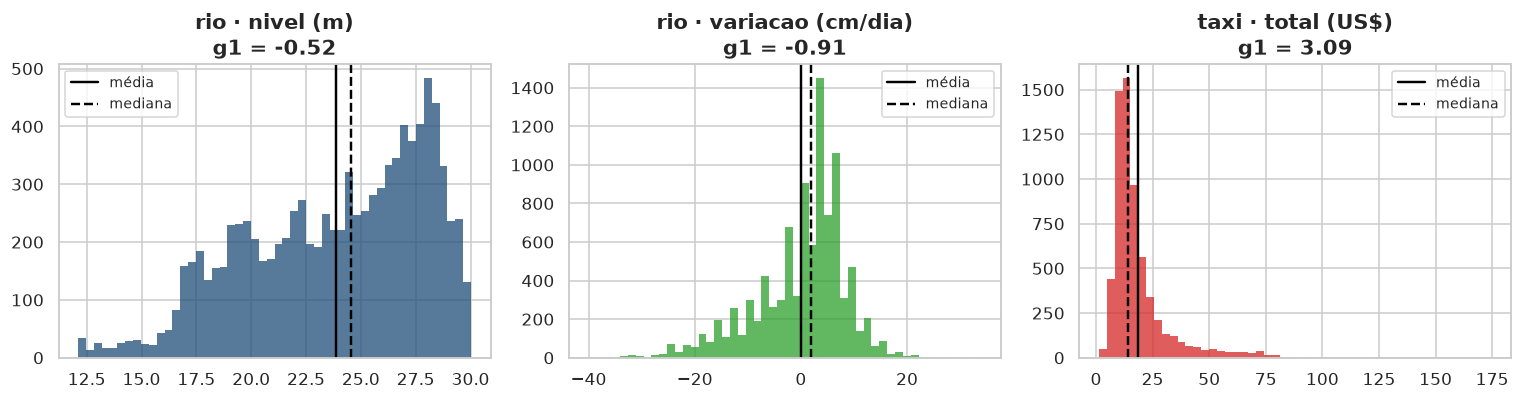

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
dados = [
    (nivel, "rio · nivel (m)", "#1f4e79"),
    (rio["variacao"], "rio · variacao (cm/dia)", "#2ca02c"),
    (total, "taxi · total (US$)", "#d62728"),
]
for ax, (serie, titulo, cor) in zip(axes, dados):
    sns.histplot(serie, bins=50, ax=ax, color=cor, edgecolor="none")
    ax.axvline(serie.mean(),   color="black", ls="-",  lw=1.6, label="média")
    ax.axvline(serie.median(), color="black", ls="--", lw=1.6, label="mediana")
    ax.set_title(f"{titulo}\ng1 = {serie.skew():.2f}")
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3.6 O que o `describe()` **não** conta

`describe()` é o primeiro comando que todo mundo aprende. É útil e é insuficiente.


In [26]:
taxi[["passengers", "distance", "fare", "tip", "total"]].describe().T

,count,mean,std,min,25%,50%,75%,max
passengers,"6,433.000",1.539,1.204,0.000,1.000,1.000,2.000,6.000
distance,"6,433.000",3.025,3.828,0.000,0.980,1.640,3.210,36.700
fare,"6,433.000",13.091,11.552,1.000,6.500,9.500,15.000,150.000
tip,"6,433.000",1.979,2.449,0.000,0.000,1.700,2.800,33.200
total,"6,433.000",18.518,13.816,1.300,10.800,14.160,20.300,174.820


### Olhe com atenção. O que está errado aí?

- `distance` tem **mínimo 0,00** → corrida de distância zero?
- `passengers` tem **mínimo 0** → corrida sem passageiro?
- `tip` tem **mediana 1,70** mas o 1º quartil é **0,00** → pelo menos 25% não deram gorjeta
- `total` vai de 1,30 a **174,82** com mediana 14,16 → cauda longuíssima

O `describe()` **mostrou** todos esses sinais. Ele não os **interpretou**.
Isso é trabalho seu.

E o que ele não mostra de jeito nenhum: **quantas modas** a distribuição tem,
onde estão os buracos, se há valores repetidos suspeitos.
Para isso, só gráfico.


---

# 4. Visualizar uma variável

Todas as estatísticas do bloco anterior são **compressões com perda**.
O gráfico é o que mostra o que foi perdido.


## 4.1 O histograma e a maldição dos _bins_

O histograma não é único: ele depende de uma escolha sua — a largura das faixas.
A mesma variável pode parecer normal, bimodal ou um serrote.


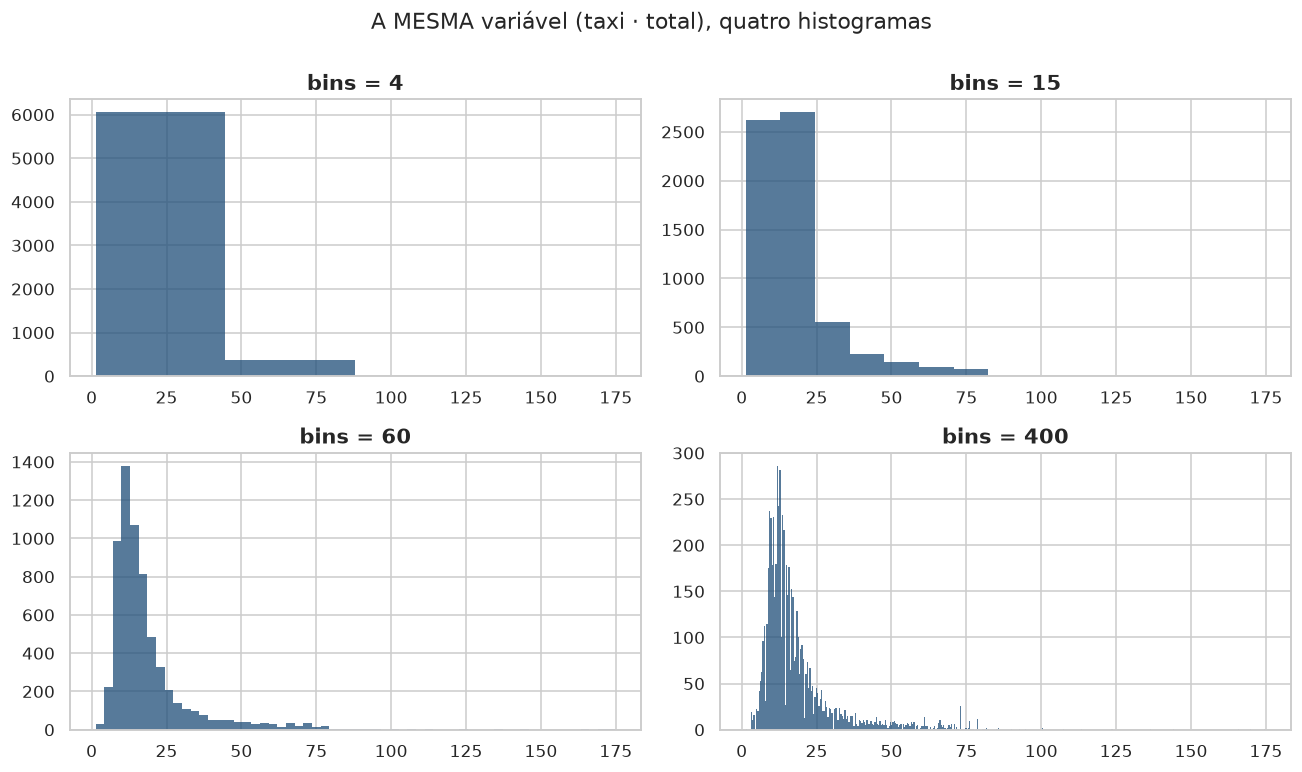

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, k in zip(axes.ravel(), [4, 15, 60, 400]):
    sns.histplot(total, bins=k, ax=ax, color="#1f4e79", edgecolor="none")
    ax.set_title(f"bins = {k}")
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("A MESMA variável (taxi · total), quatro histogramas", y=1.00)
plt.tight_layout()
plt.show()

### Regras automáticas para o número de bins

**Sturges (1926)** — assume distribuição aproximadamente normal:

$$k = \lceil \log_2 n \rceil + 1$$

**Freedman–Diaconis (1981)** — usa o IQR, portanto é **robusto** a outliers:

$$
h = 2 \cdot \frac{\mathrm{IQR}}{\sqrt[3]{n}}
\qquad\Rightarrow\qquad
k = \left\lceil \frac{\max - \min}{h} \right\rceil
$$

Sturges subestima o número de bins em amostras grandes ou assimétricas.
**Na dúvida, use Freedman–Diaconis.**


In [28]:
def n_bins(serie):
    s = serie.dropna().to_numpy()
    n = len(s)
    k_sturges = int(np.ceil(np.log2(n)) + 1)
    iqr = np.subtract(*np.percentile(s, [75, 25]))
    h_fd = 2 * iqr / np.cbrt(n)
    k_fd = int(np.ceil((s.max() - s.min()) / h_fd))
    return k_sturges, k_fd


for nome, serie in [("rio · nivel", nivel), ("taxi · total", total)]:
    ks, kfd = n_bins(serie)
    print(f"{nome:>15}  (n={len(serie):,})   Sturges = {ks:>3}   Freedman-Diaconis = {kfd:>3}")

    rio · nivel  (n=9,732)   Sturges =  15   Freedman-Diaconis =  29
   taxi · total  (n=6,433)   Sturges =  14   Freedman-Diaconis = 170


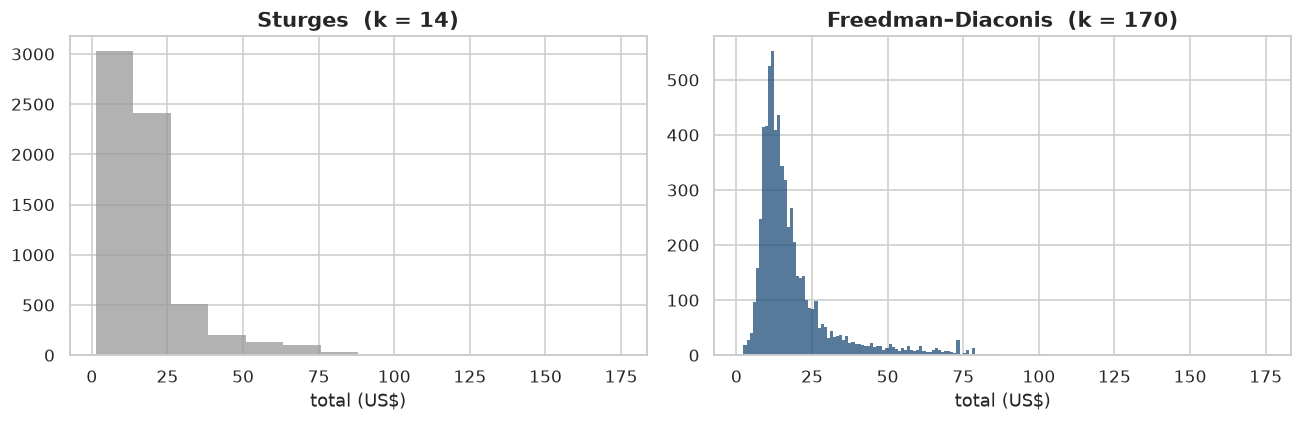

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ks, kfd = n_bins(total)
sns.histplot(total, bins=ks,  ax=axes[0], color="#999999", edgecolor="none")
axes[0].set_title(f"Sturges  (k = {ks})")
sns.histplot(total, bins=kfd, ax=axes[1], color="#1f4e79", edgecolor="none")
axes[1].set_title(f"Freedman–Diaconis  (k = {kfd})")
for ax in axes:
    ax.set_xlabel("total (US$)")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

> 💡 **Opcional (pode falhar em alguns ambientes):** a célula abaixo cria um
> controle deslizante para explorar o efeito dos bins ao vivo. Se der erro, ignore —
> nada depende dela.


In [30]:
try:
    from ipywidgets import interact, IntSlider

    @interact(bins=IntSlider(min=3, max=300, step=1, value=30, description="bins"))
    def _(bins):
        fig, ax = plt.subplots(figsize=(9, 3.5))
        sns.histplot(total, bins=bins, ax=ax,
                     color="#1f4e79", edgecolor="none")
        ax.set_title(f"taxi · total — bins = {bins}")
        ax.set_xlabel("US$")
        ax.set_ylabel("")
        plt.show()
except Exception as erro:
    print("Widget indisponível neste ambiente:", erro)

Widget indisponível neste ambiente: No module named 'ipywidgets'


## 4.2 KDE: o histograma sem bins (mas com outra escolha)

A estimativa de densidade por kernel troca o problema da **largura do bin**
pelo problema da **largura de banda** (_bandwidth_). Não há almoço grátis.


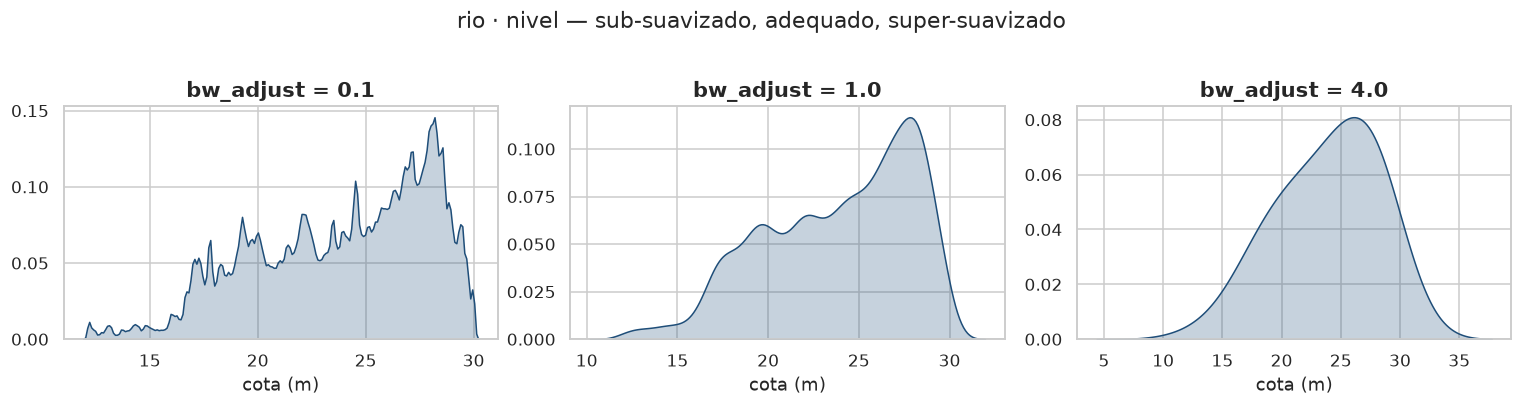

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, bw in zip(axes, [0.1, 1.0, 4.0]):
    sns.kdeplot(nivel, bw_adjust=bw, ax=ax, fill=True, color="#1f4e79")
    ax.set_title(f"bw_adjust = {bw}")
    ax.set_xlabel("cota (m)")
    ax.set_ylabel("")
fig.suptitle("rio · nivel — sub-suavizado, adequado, super-suavizado", y=1.02)
plt.tight_layout()
plt.show()

⚠️ **Cuidado com KDE em variáveis limitadas.** A curva "vaza" para além do domínio
válido: uma gorjeta negativa, uma distância negativa. O KDE não sabe que aquilo é impossível.


## 4.3 O boxplot, dissecado

```
                    ┌───────┬────────┐
     ├──────────────┤       │        ├──────────────┤        ● ●   ●
                    └───────┴────────┘
    limite         Q1     mediana    Q3            limite   pontos
   inferior                                       superior  além dos
                                                            limites
   Q1 − 1.5·IQR                              Q3 + 1.5·IQR
```

**Os "whiskers" NÃO são $Q_1 - 1{,}5 \cdot IQR$ e $Q_3 + 1{,}5 \cdot IQR$.**
Eles são o **último dado observado dentro desse intervalo**. É uma diferença
que quase todo mundo erra.

E o fator 1,5? É uma convenção de Tukey. Não tem teorema por trás.


IQR = 6.64 m
Limites de Tukey  : [10.74 ; 37.31]
Whiskers de fato  : [12.11 ; 30.02]


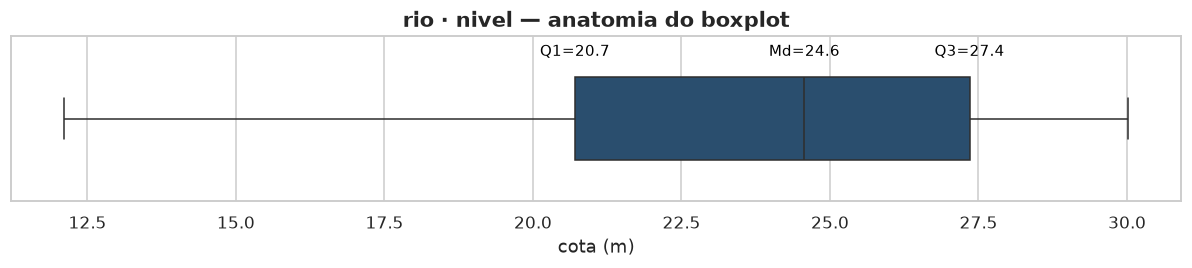

In [32]:
fig, ax = plt.subplots(figsize=(11, 2.6))
sns.boxplot(x=nivel, ax=ax, color="#1f4e79", width=0.5, fliersize=2)

q1, q2, q3 = nivel.quantile([.25, .50, .75])
iqr = q3 - q1
for valor, rotulo in [(q1, f"Q1={q1:.1f}"), (q2, f"Md={q2:.1f}"), (q3, f"Q3={q3:.1f}")]:
    ax.annotate(rotulo, xy=(valor, -0.38), ha="center",
                fontsize=10, color="black")

ax.set_title("rio · nivel — anatomia do boxplot")
ax.set_xlabel("cota (m)")
print(f"IQR = {iqr:.2f} m")
print(f"Limites de Tukey  : [{q1 - 1.5*iqr:.2f} ; {q3 + 1.5*iqr:.2f}]")
print(f"Whiskers de fato  : [{nivel[nivel >= q1 - 1.5*iqr].min():.2f} ; "
      f"{nivel[nivel <= q3 + 1.5*iqr].max():.2f}]")
plt.tight_layout()
plt.show()

## 4.4 O que o boxplot esconde

O boxplot mostra cinco números. Distribuições muito diferentes podem
ter os mesmos cinco números.

Vamos olhar `tip` — a gorjeta.


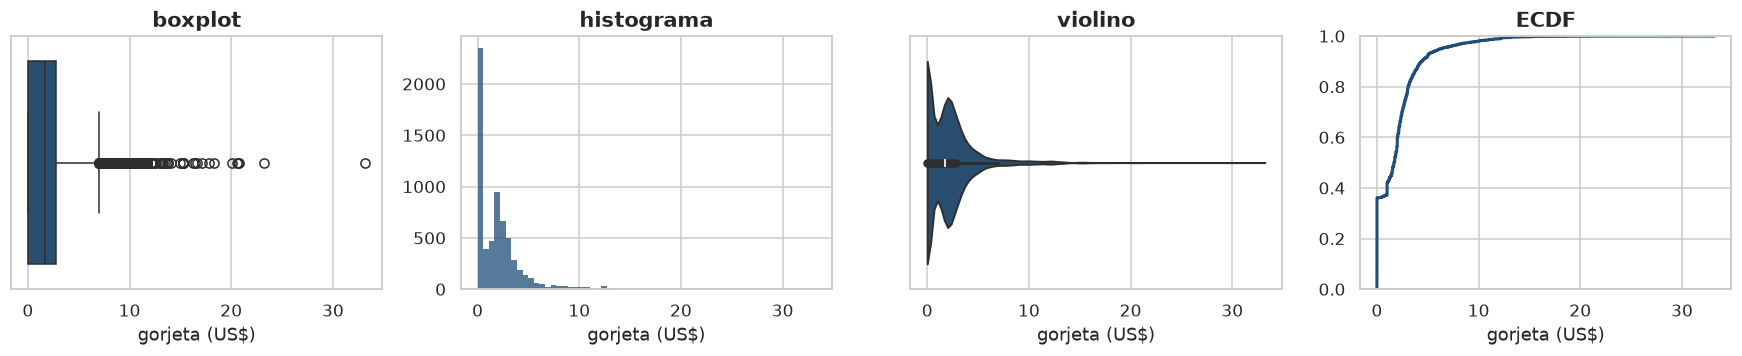

média   = 1.98
mediana = 1.70
proporção de gorjetas EXATAMENTE iguais a zero: 35.9%


In [33]:
tip = taxi["tip"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))

sns.boxplot(x=tip, ax=axes[0], color="#1f4e79")
axes[0].set_title("boxplot")
sns.histplot(tip, bins=60, ax=axes[1], color="#1f4e79", edgecolor="none")
axes[1].set_title("histograma")
sns.violinplot(x=tip, ax=axes[2], color="#1f4e79", cut=0)
axes[2].set_title("violino")
sns.ecdfplot(tip, ax=axes[3], color="#1f4e79", lw=2)
axes[3].set_title("ECDF")

for ax in axes:
    ax.set_xlabel("gorjeta (US$)")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"média   = {tip.mean():.2f}")
print(f"mediana = {tip.median():.2f}")
print(
    f"proporção de gorjetas EXATAMENTE iguais a zero: {(tip == 0).mean():.1%}")

### O achado

**36% das corridas têm gorjeta exatamente zero.**

A distribuição não é contínua: é uma **massa pontual em zero** grudada numa
distribuição contínua à direita. Chamamos isso de _zero-inflated_.

- A **média** (1,98) é um valor que quase ninguém pagou.
- A **mediana** (1,70) idem.
- Nenhuma das duas descreve os 36%.

O boxplot sozinho não denuncia isso. O histograma e a ECDF denunciam na hora.

> Guardem: **por que 36% pagaram zero?** Bloco 6.


## 4.5 A ECDF: o gráfico subestimado

A função de distribuição empírica acumulada:

$$
\hat{F}(t) = \frac{1}{n}\sum_{i=1}^{n} \mathbb{1}\{x_i \le t\}
$$

**Vantagens sobre o histograma:**

- não tem nenhum parâmetro para escolher (nada de bins, nada de bandwidth)
- usa todos os dados, sem agregação
- lê-se percentil direto no eixo vertical
- degraus verticais denunciam valores repetidos

**Desvantagem:** é menos intuitiva para leigos. Use em análise, não em relatório executivo.


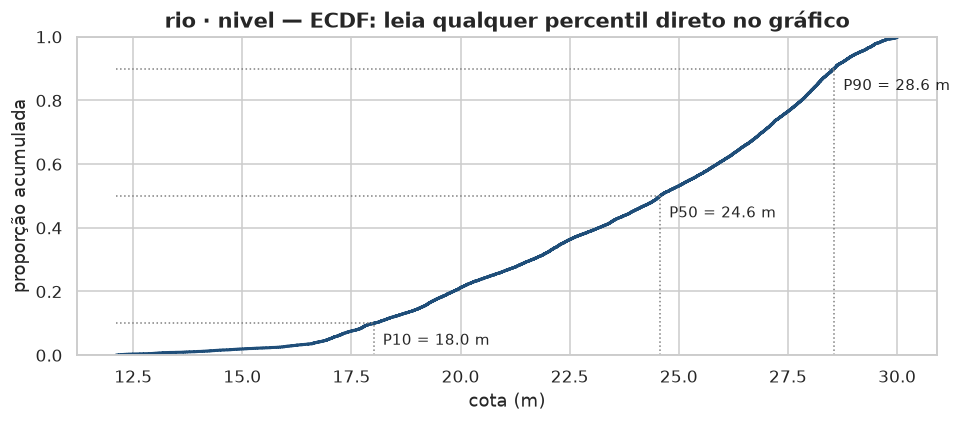

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.ecdfplot(nivel, ax=ax, lw=2, color="#1f4e79")

for p in [0.10, 0.50, 0.90]:
    q = nivel.quantile(p)
    ax.plot([nivel.min(), q], [p, p], ls=":", color="gray", lw=1)
    ax.plot([q, q], [0, p], ls=":", color="gray", lw=1)
    ax.annotate(f"P{int(p*100)} = {q:.1f} m", xy=(q, p), xytext=(6, -14),
                textcoords="offset points", fontsize=10)

ax.set_title("rio · nivel — ECDF: leia qualquer percentil direto no gráfico")
ax.set_xlabel("cota (m)")
ax.set_ylabel("proporção acumulada")
plt.tight_layout()
plt.show()

## 4.6 Escala logarítmica

Quando a variável cobre várias ordens de grandeza, o eixo linear
espreme 99% dos dados num canto.


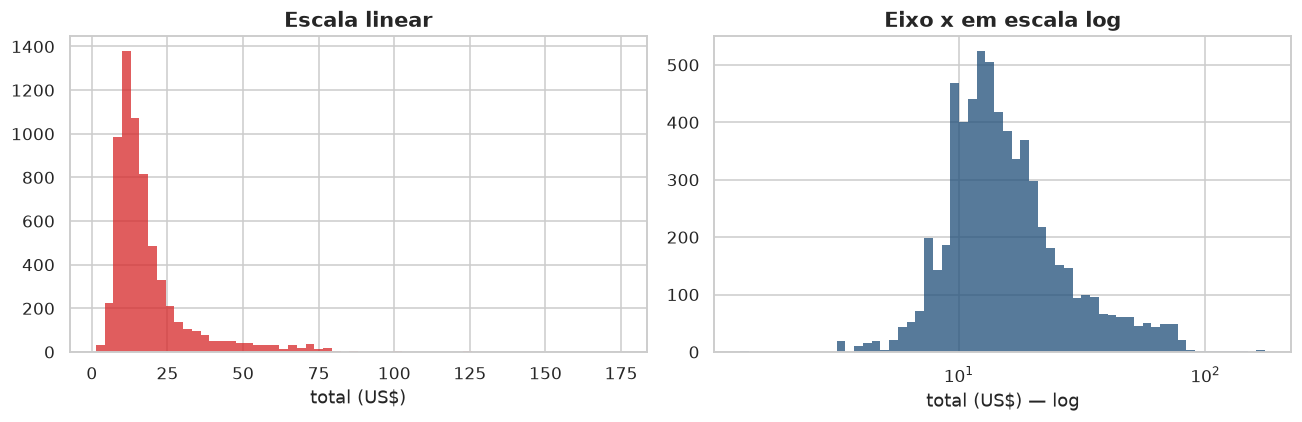

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(total, bins=60, ax=axes[0], color="#d62728", edgecolor="none")
axes[0].set_title("Escala linear")
axes[0].set_xlabel("total (US$)")

sns.histplot(total, bins=60,
             ax=axes[1], color="#1f4e79", edgecolor="none", log_scale=True)
axes[1].set_title("Eixo x em escala log")
axes[1].set_xlabel("total (US$) — log")

for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

> Mudar a **escala do eixo** é uma decisão de _visualização_.
> Aplicar $\log$ à **variável** é uma decisão de _modelagem_.
> São coisas diferentes — voltamos a isso no Bloco 7.


---

# 6. Outliers e dados faltantes

O bloco onde a análise univariada deixa de ser descrição e vira **decisão**.


## 6.1 Dois critérios clássicos para outlier

**Regra de Tukey (IQR)** — robusta, não assume distribuição:

$$
x < Q_1 - 1{,}5\cdot\mathrm{IQR}
\quad\text{ou}\quad
x > Q_3 + 1{,}5\cdot\mathrm{IQR}
$$

**Escore-z** — assume aproximadamente normal:

$$
|z_i| = \left|\frac{x_i - \bar{x}}{s}\right| > 3
$$

O escore-z tem um problema circular: $\bar{x}$ e $s$ são **contaminados pelo próprio
outlier** que você quer detectar. Por isso existe o **escore-z modificado**, baseado na MAD:

$$
M_i = \frac{0{,}6745\,(x_i - \tilde{x})}{\mathrm{MAD}}
$$


In [36]:
def detectar_outliers(serie):
    s = serie.dropna()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    por_iqr = (s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)

    z = (s - s.mean()) / s.std()
    por_z = z.abs() > 3

    mad = (s - s.median()).abs().median()
    m = 0.6745 * (s - s.median()) / \
        mad if mad > 0 else pd.Series(0, index=s.index)
    por_mad = m.abs() > 3.5

    return pd.Series({
        "Tukey (IQR)":        f"{por_iqr.sum():>5}  ({por_iqr.mean():6.2%})",
        "escore-z > 3":       f"{por_z.sum():>5}  ({por_z.mean():6.2%})",
        "z modificado > 3,5": f"{por_mad.sum():>5}  ({por_mad.mean():6.2%})",
    })


pd.DataFrame({
    "rio · nivel":   detectar_outliers(nivel),
    "taxi · total":  detectar_outliers(total),
    "taxi · distance": detectar_outliers(taxi["distance"]),
})

,rio · nivel,taxi · total,taxi · distance
Tukey (IQR),0 ( 0.00%),600 ( 9.33%),734 (11.41%)
escore-z > 3,0 ( 0.00%),185 ( 2.88%),195 ( 3.03%)
"z modificado > 3,5",0 ( 0.00%),560 ( 8.71%),812 (12.62%)


### Leia a tabela com atenção

- No **rio** (quase simétrico), os três critérios concordam razoavelmente.
- No **táxi** (assimétrico), a regra de Tukey marca **~9%** das corridas como "outliers".

Nove por cento não são outliers. São **a cauda natural de uma distribuição assimétrica**.

> **Regra de Tukey pressupõe simetria aproximada.**
> Aplicá-la a dados assimétricos gera falsos positivos em massa. Em variável
> com cauda pesada, aplique o critério **na escala log**, ou use um critério ajustado.


In [37]:
# O mesmo critério, aplicado ao log
log_total = np.log(total[total > 0])
pd.DataFrame({
    "total (escala original)": detectar_outliers(total),
    "log(total)":              detectar_outliers(log_total),
})

,total (escala original),log(total)
Tukey (IQR),600 ( 9.33%),294 ( 4.57%)
escore-z > 3,185 ( 2.88%),22 ( 0.34%)
"z modificado > 3,5",560 ( 8.71%),93 ( 1.45%)


## 6.2 Outlier ≠ erro

Três coisas completamente diferentes costumam receber o mesmo nome:

|                           | O que é                                       | O que fazer                                        |
| ------------------------- | --------------------------------------------- | -------------------------------------------------- |
| **Erro**                  | digitação, unidade errada, sensor com defeito | corrigir ou remover — e **documentar**             |
| **Evento raro legítimo**  | a vazante de 2024, a corrida ao aeroporto     | **manter**. É o dado mais informativo que você tem |
| **Mistura de populações** | táxi comum + tarifa fixa de aeroporto         | **segmentar**, não remover                         |

> Remover outlier "porque estraga o gráfico" é fraude, não limpeza.
> A decisão precisa de uma justificativa de **domínio**, não de estética.


In [38]:
# Valores IMPOSSÍVEIS — nenhum critério estatístico os detecta
print(f"Corridas com distância exatamente 0 : {(taxi['distance'] == 0).sum()}")
print(
    f"Corridas com 0 passageiros          : {(taxi['passengers'] == 0).sum()}")

q1, q3 = taxi["distance"].quantile([.25, .75])
iqr = q3 - q1
print(f"\nLimite inferior de Tukey para distance: {q1 - 1.5*iqr:.2f}")
print("→ zero está DENTRO do intervalo aceitável. A regra não vê nada de errado.")

Corridas com distância exatamente 0 : 51
Corridas com 0 passageiros          : 96

Limite inferior de Tukey para distance: -2.36
→ zero está DENTRO do intervalo aceitável. A regra não vê nada de errado.


## 6.3 O código sentinela: quando o ausente se disfarça de número

Voltemos à pergunta do Bloco 0.


In [39]:
zeros_rio = rio[rio["nivel"] == 0]
print(f"Dias com cota registrada como 0,00 m: {len(zeros_rio)}\n")
print(zeros_rio[["data", "nivel", "variacao"]].to_string(index=False))

Dias com cota registrada como 0,00 m: 4

      data  nivel  variacao
2009-05-31  0.000     0.000
2010-01-09  0.000     0.000
2010-08-07  0.000     0.000
2010-12-22  0.000     0.000


In [40]:
# O que havia nos dias vizinhos?
alvo = zeros_rio["data"].iloc[0]
janela = rio[(rio["data"] >= alvo - pd.Timedelta(days=3)) &
             (rio["data"] <= alvo + pd.Timedelta(days=3))]
print(janela[["data", "nivel"]].to_string(index=False))

      data  nivel
2009-05-28 29.110
2009-05-29 29.120
2009-05-30 29.130
2009-05-31  0.000
2009-06-01 29.150
2009-06-02 29.160
2009-06-03 29.160


### O rio não secou em 2009

O nível estava perto de 29 m no dia anterior e no dia seguinte.
**`0.00` não é uma medição — é um código de "não medido"** que ninguém documentou.

Consequência se você não perceber:

|               | com os zeros | sem os zeros |
| ------------- | ------------ | ------------ |
| mínimo        | 0,00 m       | 12,11 m      |
| média         | contaminada  | correta      |
| desvio padrão | inflado      | correto      |

E note **como** descobrimos: o `min` do `describe()`. A estatística mais simples
de todas foi a que salvou a análise.

> Códigos sentinela comuns na vida real: `0`, `-1`, `-999`, `9999`, `99`,
> `"N/A"`, `"-"`, `""`, `1900-01-01`.
> **Sempre olhe o mínimo e o máximo antes de qualquer outra coisa.**


## 6.4 Ausência explícita: `NaN`

E o mecanismo por trás da ausência importa mais do que a quantidade.


In [41]:
ausentes = pd.DataFrame({
    "n_ausentes": taxi.isna().sum(),
    "% ausentes": taxi.isna().mean() * 100,
})
ausentes[ausentes["n_ausentes"] > 0]

,n_ausentes,% ausentes
payment,44,0.684
pickup_zone,26,0.404
dropoff_zone,45,0.700
pickup_borough,26,0.404
dropoff_borough,45,0.700


### Os três mecanismos (Rubin, 1976)

| Sigla    | Nome                           | Significa                                              | Exemplo                              |
| -------- | ------------------------------ | ------------------------------------------------------ | ------------------------------------ |
| **MCAR** | _missing completely at random_ | ausência independente de tudo                          | falha aleatória do sensor            |
| **MAR**  | _missing at random_            | ausência explicada por **outras variáveis observadas** | zona ausente só em corridas do Bronx |
| **MNAR** | _missing not at random_        | ausência depende do **próprio valor não observado**    | quem ganha muito não declara renda   |

Só MCAR permite descartar linhas sem introduzir viés.
E MCAR quase nunca é o caso.


## 6.5 O caso das gorjetas — MNAR na prática

Lembram dos 36% de gorjetas iguais a zero?


In [42]:
resumo_gorjeta = taxi.groupby("payment")["tip"].agg(
    n="size",
    prop_zero=lambda s: (s == 0).mean(),
    media="mean",
    mediana="median",
)
resumo_gorjeta

,n,prop_zero,media,mediana
payment,,,,
cash,1812,1.000,0.000,0.000
credit card,4577,0.099,2.782,2.200


### O achado

**100% das corridas pagas em dinheiro têm gorjeta registrada como zero.**
Contra ~10% nas pagas com cartão.

Ninguém acredita que nenhum passageiro que pagou em dinheiro tenha dado gorjeta.
O que acontece é que **a gorjeta em dinheiro não passa pelo taxímetro** —
ela simplesmente não é registrada.

Ou seja: aqueles zeros **não são zeros**. São ausências. E são **MNAR**:
o valor está faltando _porque_ foi pago em dinheiro, e o pagamento em dinheiro
está associado ao próprio valor.


In [43]:
# O impacto quantitativo da decisão
cartao = taxi.loc[taxi["payment"] == "credit card", "tip"]

print(
    f"Gorjeta média — todas as corridas         : US$ {taxi['tip'].mean():.2f}")
print(f"Gorjeta média — só cartão (dado confiável): US$ {cartao.mean():.2f}")
print(f"\nDiferença: {cartao.mean() / taxi['tip'].mean() - 1:+.1%}")

Gorjeta média — todas as corridas         : US$ 1.98
Gorjeta média — só cartão (dado confiável): US$ 2.78

Diferença: +40.6%


> Uma análise que reportasse "a gorjeta média em Nova York é US\$ 1,98"
> estaria errada em **quase 40%** — e o erro não vem de nenhuma conta mal feita.
> Vem de não ter perguntado _por que_ aqueles zeros estão ali.


In [44]:
# E o efeito do dropna() indiscriminado
print(f"Linhas originais              : {len(taxi):,}")
print(f"Após taxi.dropna()            : {len(taxi.dropna()):,}")
print(
    f"Perda                         : {1 - len(taxi.dropna())/len(taxi):.2%}")
print("\nA perda é pequena aqui. Em bases com 20 colunas e 5% de ausência")
print("em cada uma, dropna() pode eliminar mais da metade das linhas.")

Linhas originais              : 6,433
Após taxi.dropna()            : 6,341
Perda                         : 1.43%

A perda é pequena aqui. Em bases com 20 colunas e 5% de ausência
em cada uma, dropna() pode eliminar mais da metade das linhas.


---

# 7. Normalidade e transformações

## Por que a normal importa

Não porque "os dados são normais" — quase nunca são.
Mas porque **muitos métodos que vocês vão usar depois assumem normalidade**:
intervalos de confiança clássicos, testes t, ANOVA, regressão linear (nos resíduos),
regra dos 3 sigmas.

Verificar isso é tarefa da análise univariada.


## 7.1 O QQ-plot

Compare os quantis empíricos com os quantis teóricos da normal.
Se a variável for normal, os pontos caem sobre a reta.

**A forma do desvio informa o tipo de desvio:**

| Padrão no QQ-plot               | Diagnóstico                   |
| ------------------------------- | ----------------------------- |
| curva para cima nas duas pontas | cauda pesada à direita        |
| "S" deitado                     | caudas pesadas dos dois lados |
| ponta direita acima da reta     | assimetria positiva           |
| pontos isolados nas pontas      | outliers                      |


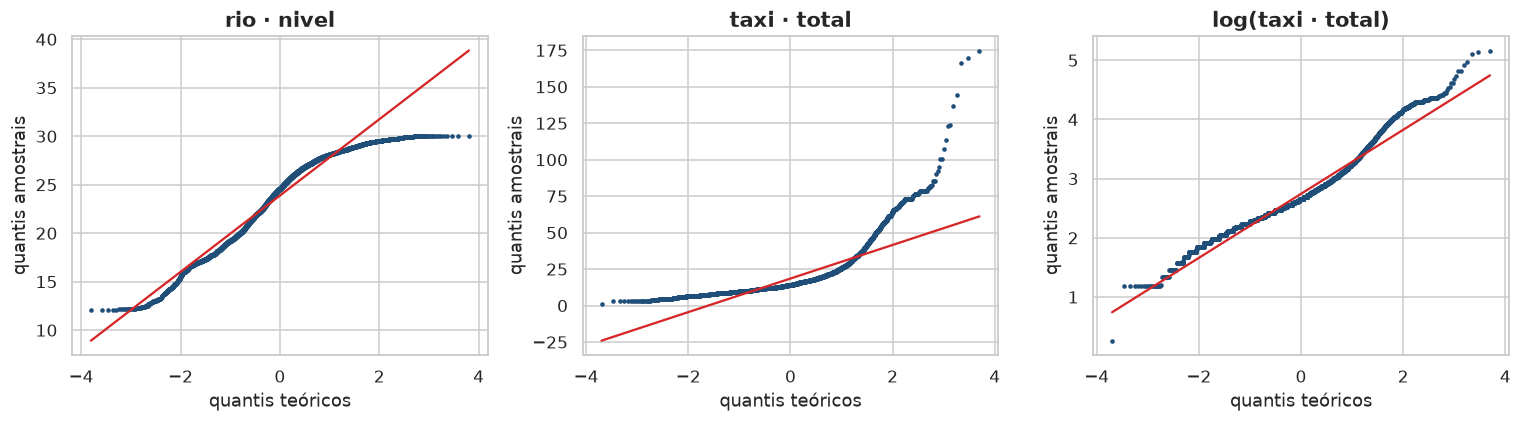

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (serie, titulo) in zip(axes, [
    (nivel,          "rio · nivel"),
    (total,          "taxi · total"),
    (np.log(total),  "log(taxi · total)"),
]):
    stats.probplot(serie, dist="norm", plot=ax)
    ax.set_title(titulo)
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[0].set_color("#1f4e79")
    ax.get_lines()[1].set_color("#d62728")
    ax.set_xlabel("quantis teóricos")
    ax.set_ylabel("quantis amostrais")

plt.tight_layout()
plt.show()

## 7.2 Testes de normalidade e a armadilha do $n$ grande

O teste de Shapiro–Wilk tem $H_0$: "a amostra vem de uma normal".

**O problema:** com $n$ grande, qualquer desvio ínfimo da normalidade
produz $p < 0{,}05$. O teste passa a responder "a amostra é grande?"
em vez de "a distribuição é normal?".


In [46]:
rng = np.random.default_rng(1)

populacoes = {
    "A) Normal perfeita":              rng.normal(0, 1, 100_000),
    "B) Normal ARREDONDADA a 1 casa":  np.round(rng.normal(0, 1, 100_000), 1),
    "C) t de Student (df=15)":         rng.standard_t(15, 100_000),
    "D) rio · nivel (dado real)":      rng.permutation(nivel.to_numpy()),
}

print(f"{'população':<34}{'n=50':>12}{'n=500':>12}{'n=5.000':>12}")
print("-" * 70)
for nome, populacao in populacoes.items():
    linha = f"{nome:<34}"
    for n in (50, 500, 5_000):
        p = stats.shapiro(populacao[:n]).pvalue
        marca = "*" if p < 0.05 else " "
        linha += f"{p:>11.1e}{marca}"
    print(linha)
print("\n*  = p < 0,05, ou seja, o teste REJEITA a normalidade")

população                                 n=50       n=500     n=5.000
----------------------------------------------------------------------
A) Normal perfeita                    3.2e-01     2.9e-01     3.8e-01 
B) Normal ARREDONDADA a 1 casa        8.0e-01     5.7e-01     1.1e-04*
C) t de Student (df=15)               9.6e-01     8.2e-01     5.4e-04*
D) rio · nivel (dado real)            8.1e-03*    2.5e-14*    4.9e-39*

*  = p < 0,05, ou seja, o teste REJEITA a normalidade


### Leia a tabela por linha

- **(A)** Normal de verdade: nunca é rejeitada. O teste funciona.
- **(B)** A _mesma_ normal, apenas **arredondada a uma casa decimal** — exatamente
  o que todo instrumento de medição faz. Passa em $n=50$ e $n=500$; é **rejeitada**
  em $n=5.000$.
- **(C)** Uma $t$ de Student com 15 graus de liberdade é praticamente indistinguível
  de uma normal a olho nu. Mesmo padrão: passa em $n$ pequeno, é rejeitada em $n=5.000$.
- **(D)** O dado real é rejeitado em todos os tamanhos — e aqui **com razão**,
  porque a assimetria é grande de verdade ($g_1 = -0{,}52$).

> O que muda entre as colunas não é a distribuição: é o **poder do teste**.
> Com $n$ grande, o Shapiro–Wilk detecta desvios reais mas **irrelevantes**,
> como o arredondamento do instrumento.
>
> **Conclusão prática:** use o QQ-plot para _decidir_, e o teste no máximo
> como evidência auxiliar em amostras pequenas. E pergunte sempre:
> "o desvio da normalidade é grande o bastante para **importar** para o que vou fazer?"


## 7.3 Transformações

| Transformação | Quando usar                                      | Cuidado                         |
| ------------- | ------------------------------------------------ | ------------------------------- |
| $\log(x)$     | assimetria positiva forte, escala multiplicativa | exige $x > 0$                   |
| $\log(1+x)$   | idem, mas com zeros                              | muda a interpretação perto de 0 |
| $\sqrt{x}$    | contagens, assimetria moderada                   | mais suave que o log            |
| $1/x$         | assimetria extrema                               | inverte a ordem!                |
| **Box–Cox**   | escolhe $\lambda$ automaticamente                | exige $x > 0$                   |

$$
x^{(\lambda)} =
\begin{cases}
\dfrac{x^{\lambda} - 1}{\lambda}, & \lambda \neq 0 \\[8pt]
\log x, & \lambda = 0
\end{cases}
$$


In [47]:
positivos = total[total > 0]
transformado, lam = stats.boxcox(positivos)

print(f"Lambda ótimo estimado: {lam:.3f}")
print("(λ ≈ 1 → nenhuma transformação; λ ≈ 0,5 → raiz; λ ≈ 0 → log; λ < 0 → mais forte que o log)\n")

comparacao = pd.DataFrame({
    "assimetria": [positivos.skew(),
                   pd.Series(np.log(positivos)).skew(),
                   pd.Series(np.sqrt(positivos)).skew(),
                   pd.Series(transformado).skew()],
    "curtose":    [positivos.kurt(),
                   pd.Series(np.log(positivos)).kurt(),
                   pd.Series(np.sqrt(positivos)).kurt(),
                   pd.Series(transformado).kurt()],
}, index=["original", "log", "raiz quadrada", f"Box-Cox (λ={lam:.2f})"])
comparacao

Lambda ótimo estimado: -0.372
(λ ≈ 1 → nenhuma transformação; λ ≈ 0,5 → raiz; λ ≈ 0 → log; λ < 0 → mais forte que o log)



,assimetria,curtose
original,3.093,15.066
log,0.737,0.958
raiz quadrada,1.761,4.196
Box-Cox (λ=-0.37),-0.049,1.134


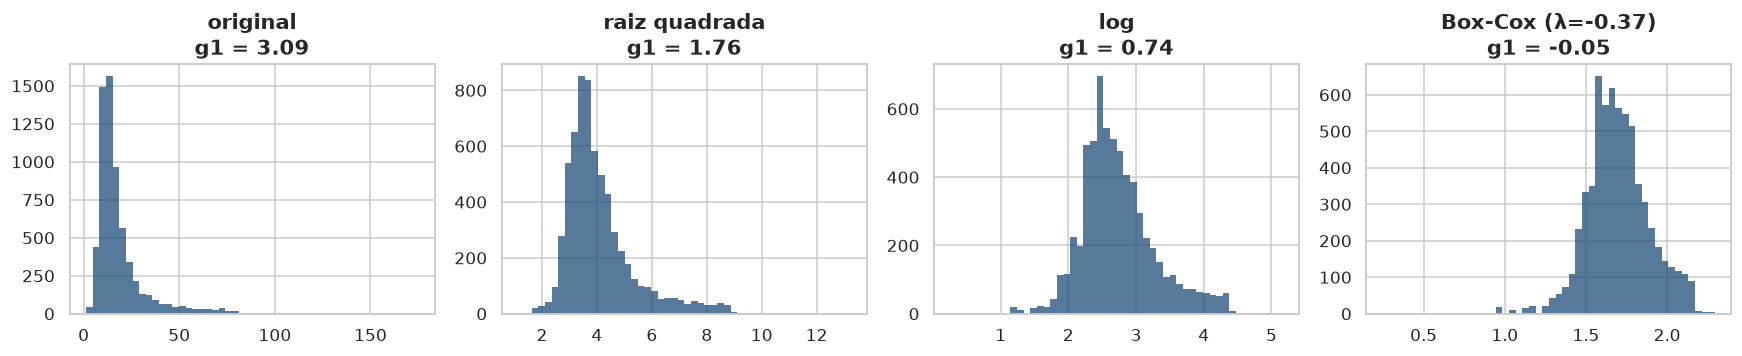

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
series = [
    (positivos,             "original"),
    (np.sqrt(positivos),    "raiz quadrada"),
    (np.log(positivos),     "log"),
    (pd.Series(transformado), f"Box-Cox (λ={lam:.2f})"),
]
for ax, (serie, titulo) in zip(axes, series):
    sns.histplot(serie, bins=50, ax=ax, color="#1f4e79", edgecolor="none")
    ax.set_title(f"{titulo}\ng1 = {pd.Series(np.asarray(serie)).skew():.2f}")
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

### O preço da transformação

Você ganha simetria e perde **interpretabilidade**.

A média de $\log(x)$ **não é** o log da média. Ao voltar para a escala original,
$e^{\overline{\log x}}$ é a **média geométrica** — que é sempre menor que a média
aritmética e responde a uma pergunta diferente.

> Transforme quando o método exigir. Reporte na escala que o leitor entende.


---

# 8. Fechamento

## Checklist de análise univariada

Para **cada** variável, nesta ordem:

1. **Classifique** — qualitativa ou quantitativa? Qual escala de medida?
2. **Olhe os extremos primeiro** — `min` e `max`. Eles são plausíveis?
   Códigos sentinela aparecem aqui.
3. **Conte as ausências** — `isna().sum()`, e também os "ausentes disfarçados"
   (zeros, `-999`, strings vazias).
4. **Resuma numericamente** — medidas apropriadas à escala; sempre média **e** mediana.
5. **Plote** — histograma (com FD) ou barras; e uma ECDF para conferir.
6. **Investigue o que o gráfico mostrou** — multimodalidade, massa em zero,
   picos em valores redondos, buracos.
7. **Decida e documente** — o que você removeu, transformou ou manteve, e **por quê**.


## Sete erros comuns

1. Reportar a média de uma distribuição fortemente assimétrica sem a mediana ao lado.
2. Confiar no `dtype` como se fosse a escala de medida.
3. Aceitar o número de bins padrão do histograma.
4. Usar `value_counts()` sem `dropna=False` na primeira inspeção.
5. Aplicar a regra de Tukey a dados assimétricos e chamar 9% dos dados de "outlier".
6. Tratar zeros como valores medidos sem investigar de onde vieram.
7. Remover outliers antes de entender o que são.


## A ponte para a próxima aula

Tudo o que vimos hoje foi sobre **uma** variável isolada.

Mas várias das perguntas que apareceram só se resolvem com **duas**:

- Por que 36% das gorjetas são zero? → precisou de `payment`
- Por que `fare` tem um pico em US\$ 52? → precisa da zona de destino
- A seca de 2024 é tendência? → precisa do tempo como segunda variável

> **Próxima aula: análise bivariada.**
> Correlação, tabelas de contingência, e o motivo pelo qual a correlação
> não é o que a maioria das pessoas pensa que é.


## Referências

- Tukey, J. W. (1977). _Exploratory Data Analysis_. Addison-Wesley.
- Freedman, D. & Diaconis, P. (1981). On the histogram as a density estimator.
  _Zeitschrift für Wahrscheinlichkeitstheorie_, 57(4).
- Wilkinson, L. (2005). _The Grammar of Graphics_. Springer.
- Bussab, W. O. & Morettin, P. A. (2017). _Estatística Básica_, 9ª ed. Saraiva.
- Little, R. J. A. & Rubin, D. B. (2019). _Statistical Analysis with Missing Data_, 3ª ed. Wiley.
- Wickham, H. & Grolemund, G. _R for Data Science_ — cap. 7 (EDA). Disponível on-line.

### Sobre os dados

- **Rio Negro:** cotas diárias do Porto de Manaus, rede hidrometeorológica ANA/SGB.
  Compilação: `github.com/davidscamurca/nivel-rio-negro`.
- **Táxis:** amostra pública de corridas de NYC (2019), distribuída em `seaborn-data`.
